In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=30
)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

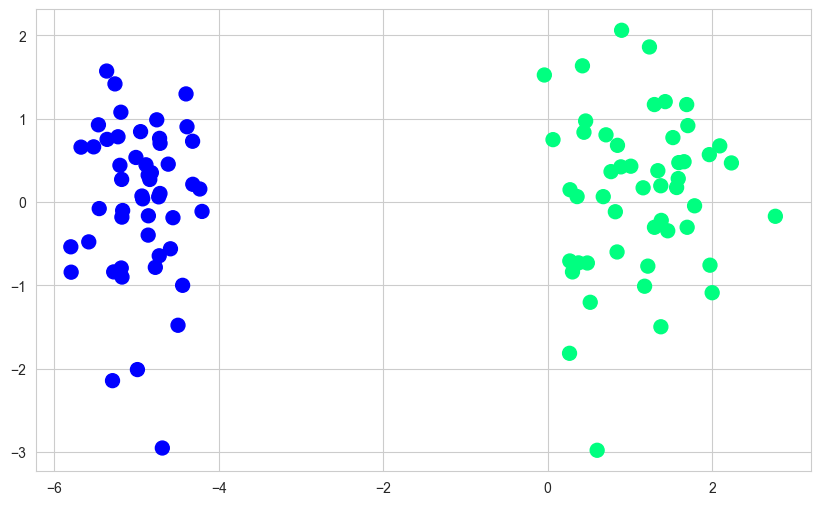

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

# Using Sklearn

[Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
class LogisticRegressionOwnClass:
    def __init__(self, epochs=100, lr=0.01):
        self.epochs = epochs
        self.lr = lr 
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X_train, y_train):
        X_train_input = np.insert(X_train,0,1, axis=1)
        weights = np.ones(X_train_input.shape[1])
        
        for _ in range(self.epochs):
            y_hat = sigmoid( np.dot(X_train_input, weights) )
            weights = weights + self.lr * (
                np.dot(X_train_input.T, (y_train - y_hat)) / X_train_input.shape[0]
            )
            
        self.intercept_ = weights[0]
        self.coef_ = weights[1:]
        
    def predict_prob(self, X):
        X_input = np.insert(X, 0, 1, axis=1)
        weights = np.insert(self.coef_, 0 , self.intercept_)
        return sigmoid( np.dot(X_input, weights) )
    
    def predict(self, X):
        probs = self.predict_prob(X)
        return (probs >= 0.5).astype(int)

In [7]:
from sklearn.metrics import accuracy_score
lr = LogisticRegressionOwnClass()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.95

In [8]:
lr.intercept_, lr.coef_

(np.float64(1.0511407623989384), array([1.10359778, 0.95691207]))

In [9]:
m = -(lr.coef_[0] / lr.coef_[1])
b = -(lr.intercept_ / lr.coef_[1])


In [10]:
x_input = np.linspace(-3, 3, 100)
y_input_lr = m * x_input + b

(-3.0, 2.0)

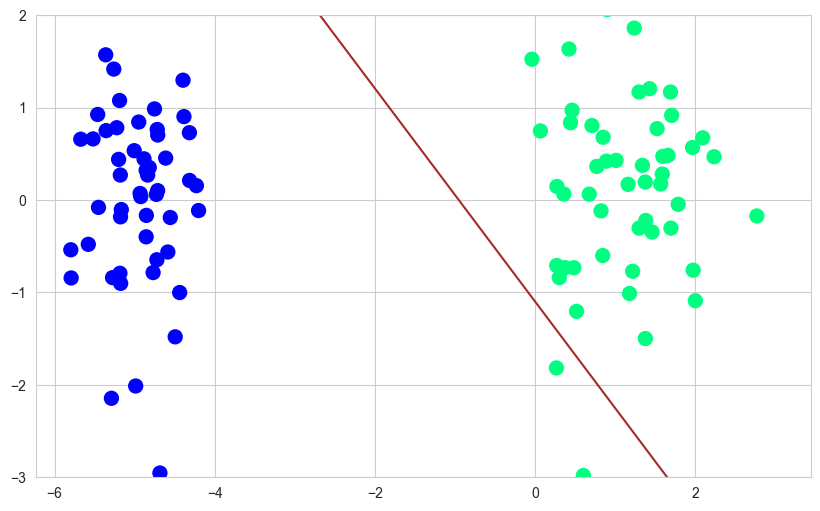

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

plt.plot(x_input, y_input_lr, color='brown')
plt.ylim(-3, 2)